# 지하철 역 이용객 수에 영향을 미치는 변수에 관한 연구 (II)
## 승법적 회귀모형을 활용한 2025년 8호선 역별 주간 인구밀도 추정

김인욱 | 가천대학교 스마트시티융합학과 석사 (202640502) · 2026.04.14.

## 1. 데이터 로드 및 전처리

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# ── 1) 역 정보 (K, L 포함) ──
station_info = pd.read_csv(r'C:\Users\inwoo\Downloads\8호선_역정보_표.csv')
print("▶ 역 정보 (8호선_역정보_표.csv)")
display(station_info)

▶ 역 정보 (8호선_역정보_표.csv)


,노선,역번호,역명,영어역명,접속노선,역간거리,누적거리,L,소재지
0,별내선,804,별내,Byeollae,수도권 전철 경춘선,0.0,0.0,3.55,경기도 남양주시
1,별내선,805,다산,Dasan,NaN,3.1,3.1,2.45,경기도 남양주시
2,별내선,806,동구릉,Donggureung,NaN,1.8,4.9,1.45,경기도 구리시
3,별내선,807,구리,Guri,수도권 전철 경의·중앙선,1.1,6.0,1.50,경기도 구리시
4,별내선,808,장자호수공원,Jangja Lake Park,NaN,1.9,7.9,2.70,서울특별시 강동구
5,별내선,809,암사역사공원,Amsa History Park,NaN,3.5,11.4,2.30,서울특별시 강동구
6,서울 지하철 8호선,810,암사,Amsa,NaN,1.1,12.5,1.20,서울특별시 강동구
7,서울 지하철 8호선,811,천호,Cheonho,수도권 전철 5호선,1.3,13.8,1.10,서울특별시 강동구
8,서울 지하철 8호선,812,강동구청,Gangdong-gu Office,NaN,0.9,14.7,1.25,서울특별시 강동구
9,서울 지하철 8호선,813,몽촌토성,Mongchontoseong,NaN,1.6,16.3,1.20,서울특별시 송파구


In [2]:
# ── 2) 수송력 상수 K ──
k_table = pd.read_csv(r'C:\Users\inwoo\Downloads\운행횟수_표_수정본.csv')
print("▶ 수송력 상수 K (운행횟수_표_수정본.csv)")
display(k_table)

▶ 수송력 상수 K (운행횟수_표_수정본.csv)


,역명,역번호,노선,길이,운행횟수,공급량,K
0,나머지,800,8,6,322,1932,1.00
1,별내,804,경춘,8,125,1000,1.52
2,구리,807,경의중앙,8,173,1384,1.72
3,천호,811,5,8,399,3192,2.65
4,잠실,814,2,10,483,4830,3.50
5,석촌,815,9,6,482,2892,2.50
6,가락시장,817,3,10,333,3330,2.72
7,복정,820,수인분당,6,336,2016,2.04
8,모란,827,수인분당,6,336,2016,2.04


In [3]:
# ── 3) 행정동 면적 ──
area_df = pd.read_csv(r'C:\Users\inwoo\Downloads\행정동_면적_통합.csv')
print("▶ 행정동 면적 (행정동_면적_통합.csv)")
display(area_df.head(10))
print(f"총 {len(area_df)}개 행정동")

▶ 행정동 면적 (행정동_면적_통합.csv)


,행정동,면적(km²)
0,풍납1동,0.77
1,풍납2동,1.59
2,거여1동,0.67
3,거여2동,1.69
4,마천1동,0.58
5,마천2동,0.89
6,방이1동,0.50
7,방이2동,0.80
8,오륜동,3.17
9,오금동,1.65


총 98개 행정동


In [4]:
# ── 4) 5세별 주민등록인구 ──
pop_df = pd.read_csv(
    r'C:\Users\inwoo\Downloads\행정구역_읍면동_별_5세별_주민등록인구_2011년__20260414155538.csv',
    encoding='euc-kr', header=[0, 1]
)
# 컬럼 정리
pop_df.columns = ['항목', '행정구역'] + [
    '계', '0~4세', '5~9세', '10~14세', '15~19세', '20~24세', '25~29세',
    '30~34세', '35~39세', '40~44세', '45~49세', '50~54세', '55~59세',
    '60~64세', '65~69세', '70~74세', '75~79세', '80~84세', '85~89세',
    '90~94세', '95~99세', '100+'
]
# 행정동 이름만 추출 (마지막 > 뒤)
pop_df['동명'] = pop_df['행정구역'].apply(lambda x: x.strip().split('>')[-1].strip() if '>' in str(x) else str(x).strip())

print("▶ 5세별 주민등록인구 (2025.12)")
display(pop_df[['동명', '계', '0~4세', '15~19세', '65~69세']].head(10))

▶ 5세별 주민등록인구 (2025.12)


,동명,계,0~4세,15~19세,65~69세
0,송파구,643350,16292,27988,43270
1,풍납1동,10753,228,341,1124
2,풍납2동,22922,626,862,1656
3,거여1동,11725,179,402,995
4,거여2동,23058,717,825,1770
5,마천1동,15169,203,612,1481
6,마천2동,16961,196,518,1807
7,방이1동,14926,293,737,1037
8,방이2동,26189,399,580,1504
9,오륜동,17522,343,1164,1255


In [5]:
# ── 5) 일평균 승하차량 (종속변수) ──
ridership_df = pd.read_csv(r'C:\Users\inwoo\Downloads\수도권전철8호선_역번호순_일평균승하차량_2008_2024_재생성.csv')
print("▶ 일평균 승하차량 (2024년 기준)")
ridership_df['y'] = ridership_df['2024']
display(ridership_df[['역번호', '역명', 'y']])

▶ 일평균 승하차량 (2024년 기준)


,역번호,역명,y
0,804,별내,18568
1,805,다산,16773
2,806,동구릉,10582
3,807,구리,37065
4,808,장자호수공원,15742
5,809,암사역사공원,10372
6,810,암사,32695
7,811,천호,71151
8,812,강동구청,20186
9,813,몽촌토성,14010


## 2. 역세권 행정동 매핑 및 변수 구축

각 역의 소재 행정동을 매핑하고, 연령대별 인구밀도(x₁₁, x₁₂, x₁₃)를 산출합니다.
- **x₁₁**: 0~14세 인구밀도 (명/km²)
- **x₁₂**: 15~64세 인구밀도 (명/km²)  
- **x₁₃**: 65세 이상 인구밀도 (명/km²)
- **K**: 수송력 상수 (8호선 = 1.00 기준)
- **L**: 인접 역 간 거리 평균 (km)

In [6]:
# ── 역 → 소재 행정동 매핑 (PDF 4.2절 기준) ──
# 인구 CSV에서의 동명은 '제'가 포함된 정식 명칭 사용
station_dong_map = {
    804: ['별내동'],
    805: ['다산1동'],
    806: ['동구동'],
    807: ['인창동'],
    808: ['수택3동', '교문2동'],
    809: ['암사제1동', '암사제3동'],
    810: ['암사제1동', '암사제2동'],
    811: ['천호제2동', '성내제2동', '풍납1동'],
    812: ['성내제1동', '풍납2동'],
    813: ['방이2동', '잠실4동'],
    814: ['잠실6동', '잠실4동'],
    815: ['석촌동', '송파1동'],
    816: ['송파2동', '가락1동'],
    817: ['가락1동', '문정2동'],
    818: ['문정1동', '문정2동'],
    819: ['장지동'],
    820: ['장지동', '복정동'],
    821: ['복정동'],
    822: ['산성동', '신흥2동'],
    823: ['단대동', '금광2동'],
    824: ['단대동', '신흥1동', '신흥2동', '산성동', '금광1동'],
    825: ['신흥3동', '중앙동'],
    826: ['수진1동', '중앙동'],
    827: ['성남동', '수진2동'],
}

# 면적 딕셔너리
area_dict = dict(zip(area_df['행정동'], area_df['면적(km²)']))

# 인구 데이터를 동명으로 인덱싱
# 숫자 컬럼 변환
age_cols = ['계', '0~4세', '5~9세', '10~14세', '15~19세', '20~24세', '25~29세',
            '30~34세', '35~39세', '40~44세', '45~49세', '50~54세', '55~59세',
            '60~64세', '65~69세', '70~74세', '75~79세', '80~84세', '85~89세',
            '90~94세', '95~99세', '100+']
for col in age_cols:
    pop_df[col] = pd.to_numeric(pop_df[col], errors='coerce')

# 동명 → 인구 데이터 딕셔너리
pop_dict = {}
for _, row in pop_df.iterrows():
    dong = row['동명']
    if dong not in pop_dict:
        pop_dict[dong] = row

print(f"면적 데이터: {len(area_dict)}개 동")
print(f"인구 데이터: {len(pop_dict)}개 동")

면적 데이터: 97개 동
인구 데이터: 105개 동


In [7]:
# ── 역별 연령대별 인구밀도 산출 ──
rows = []
for stn_id, dongs in station_dong_map.items():
    total_area = 0
    pop_0_14 = 0    # 0~14세
    pop_15_64 = 0   # 15~64세
    pop_65_plus = 0  # 65세 이상
    total_pop = 0
    
    missing = []
    for dong in dongs:
        # 면적
        a = area_dict.get(dong, None)
        # 인구
        p = pop_dict.get(dong, None)
        
        if a is None:
            missing.append(f"{dong}(면적)")
            continue
        if p is None:
            missing.append(f"{dong}(인구)")
            continue
        
        total_area += a
        total_pop += p['계']
        pop_0_14 += p['0~4세'] + p['5~9세'] + p['10~14세']
        pop_15_64 += (p['15~19세'] + p['20~24세'] + p['25~29세'] + p['30~34세'] +
                      p['35~39세'] + p['40~44세'] + p['45~49세'] + p['50~54세'] +
                      p['55~59세'] + p['60~64세'])
        pop_65_plus += (p['65~69세'] + p['70~74세'] + p['75~79세'] + p['80~84세'] +
                        p['85~89세'] + p['90~94세'] + p['95~99세'] + p['100+'])
    
    if missing:
        print(f"  역 {stn_id}: 누락 = {missing}")
    
    if total_area > 0:
        x11 = pop_0_14 / total_area
        x12 = pop_15_64 / total_area
        x13 = pop_65_plus / total_area
        night_density = total_pop / total_area
    else:
        x11 = x12 = x13 = night_density = 0
    
    rows.append({
        '역번호': stn_id,
        '행정동': ', '.join(dongs),
        '면적(km²)': round(total_area, 2),
        '야간인구': int(total_pop),
        '야간인구밀도': round(night_density, 0),
        'x11_0_14세밀도': round(x11, 1),
        'x12_15_64세밀도': round(x12, 1),
        'x13_65세이상밀도': round(x13, 1),
    })

density_df = pd.DataFrame(rows)
print("▶ 역별 연령대별 인구밀도 산출 완료")
display(density_df)

▶ 역별 연령대별 인구밀도 산출 완료


,역번호,행정동,면적(km²),야간인구,야간인구밀도,x11_0_14세밀도,x12_15_64세밀도,x13_65세이상밀도
0,804,별내동,18.63,82897,4450.0,599.0,3125.6,725.1
1,805,다산1동,5.54,105753,19089.0,3277.8,13241.9,2569.3
2,806,동구동,7.32,35104,4796.0,440.8,3475.7,879.1
3,807,인창동,2.10,23558,11218.0,1107.1,8133.8,1977.1
4,808,"수택3동, 교문2동",10.49,41526,3959.0,372.9,2842.1,743.6
5,809,"암사제1동, 암사제3동",3.53,49505,14024.0,1388.1,9607.4,3028.6
6,810,"암사제1동, 암사제2동",2.20,47214,21461.0,1810.9,14941.4,4708.6
7,811,"천호제2동, 성내제2동, 풍납1동",3.01,69818,23195.0,1382.4,16635.2,5177.7
8,812,"성내제1동, 풍납2동",2.17,41839,19281.0,1854.4,13572.8,3853.5
9,813,"방이2동, 잠실4동",2.36,47337,20058.0,2083.9,14730.5,3243.6


In [8]:
# ── 회귀분석 데이터셋 구축 ──
# K값 매핑
k_map = dict(zip(k_table['역번호'], k_table['K']))
default_k = 1.00

# station_info에서 L값 가져오기
l_map = dict(zip(station_info['역번호'], station_info['L']))

# 승하차량(y) 매핑
y_map = dict(zip(ridership_df['역번호'], ridership_df['y']))
name_map = dict(zip(station_info['역번호'], station_info['역명']))

# 통합 데이터프레임 구축
reg_rows = []
for _, row in density_df.iterrows():
    stn = row['역번호']
    reg_rows.append({
        '역번호': stn,
        '역명': name_map.get(stn, ''),
        'y': y_map.get(stn, np.nan),
        'x11': row['x11_0_14세밀도'],
        'x12': row['x12_15_64세밀도'],
        'x13': row['x13_65세이상밀도'],
        'K': k_map.get(stn, default_k),
        'L': l_map.get(stn, np.nan),
        '야간인구밀도': row['야간인구밀도'],
    })

reg_df = pd.DataFrame(reg_rows)
reg_df = reg_df.dropna(subset=['y', 'L'])

print("▶ 회귀분석 데이터셋 (24개 역)")
display(reg_df[['역번호', '역명', 'y', 'x11', 'x12', 'x13', 'K', 'L', '야간인구밀도']])

▶ 회귀분석 데이터셋 (24개 역)


,역번호,역명,y,x11,x12,x13,K,L,야간인구밀도
0,804,별내,18568,599.0,3125.6,725.1,1.52,3.55,4450.0
1,805,다산,16773,3277.8,13241.9,2569.3,1.00,2.45,19089.0
2,806,동구릉,10582,440.8,3475.7,879.1,1.00,1.45,4796.0
3,807,구리,37065,1107.1,8133.8,1977.1,1.72,1.50,11218.0
4,808,장자호수공원,15742,372.9,2842.1,743.6,1.00,2.70,3959.0
5,809,암사역사공원,10372,1388.1,9607.4,3028.6,1.00,2.30,14024.0
6,810,암사,32695,1810.9,14941.4,4708.6,1.00,1.20,21461.0
7,811,천호,71151,1382.4,16635.2,5177.7,2.65,1.10,23195.0
8,812,강동구청,20186,1854.4,13572.8,3853.5,1.00,1.25,19281.0
9,813,몽촌토성,14010,2083.9,14730.5,3243.6,1.00,1.20,20058.0


## 3. 승법적 회귀모형 (로그 변환 OLS)

### 모형 구조

$$y_{i} = e^{\beta_{11} x_{11} + \beta_{12} x_{12} + \beta_{13} x_{13}} \cdot e^{\beta_2 K} \cdot e^{-\beta_3 / L} \cdot e^{\beta_4} \cdot e^{\epsilon_i}$$

양변에 자연로그:

$$\ln(y_i) = \beta_{11} x_{11} + \beta_{12} x_{12} + \beta_{13} x_{13} + \beta_2 K - \beta_3 / L + \beta_4 + \epsilon_i$$

In [9]:
# ── 로그 변환 OLS 회귀분석 ──
reg_df['ln_y'] = np.log(reg_df['y'])
reg_df['inv_L'] = 1.0 / reg_df['L']  # -β₃/L → β₃ * (1/L), 부호는 계수에서 해석

# 독립변수 설계
X = reg_df[['x11', 'x12', 'x13', 'K', 'inv_L']].copy()
X = sm.add_constant(X)  # β₄ (절편)
y = reg_df['ln_y']

# OLS 적합
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   ln_y   R-squared:                       0.622
Model:                            OLS   Adj. R-squared:                  0.517
Method:                 Least Squares   F-statistic:                     5.918
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00210
Time:                        16:46:28   Log-Likelihood:                -13.425
No. Observations:                  24   AIC:                             38.85
Df Residuals:                      18   BIC:                             45.92
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.7013      0.371     23.485      0.0

In [10]:
# ── 회귀 계수 해석 표 ──
coef_df = pd.DataFrame({
    '변수': ['const (β₄)', 'x₁₁ (0~14세 밀도)', 'x₁₂ (15~64세 밀도)', 
             'x₁₃ (65세+ 밀도)', 'K (수송력)', '1/L (역간거리 역수)'],
    '계수': model.params.values,
    '표준오차': model.bse.values,
    't-값': model.tvalues.values,
    'p-값': model.pvalues.values,
})
coef_df['유의'] = coef_df['p-값'].apply(lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else '')))

print(f"▶ 모형 적합도: R² = {model.rsquared:.4f}, Adj R² = {model.rsquared_adj:.4f}")
print(f"  F-statistic = {model.fvalue:.2f}, p = {model.f_pvalue:.2e}")
print(f"  AIC = {model.aic:.2f}, BIC = {model.bic:.2f}")
print()
display(coef_df)

▶ 모형 적합도: R² = 0.6218, Adj R² = 0.5167
  F-statistic = 5.92, p = 2.10e-03
  AIC = 38.85, BIC = 45.92



,변수,계수,표준오차,t-값,p-값,유의
0,const (β₄),8.701260,0.370506,23.484810,5.919735e-15,***
1,x₁₁ (0~14세 밀도),0.000044,0.000178,0.246887,8.077892e-01,
2,x₁₂ (15~64세 밀도),-0.000026,0.000067,-0.389731,7.013080e-01,
3,x₁₃ (65세+ 밀도),0.000127,0.000197,0.645101,5.269995e-01,
4,K (수송력),0.735165,0.143280,5.130985,6.998372e-05,***
5,1/L (역간거리 역수),0.154889,0.390724,0.396415,6.964590e-01,


## 4. 잔차 분석 및 주간 인구밀도 역추정

모형의 잔차($\hat{\epsilon}_i$)를 활용하여 주간 활동 인구밀도를 추정합니다.

$$\hat{x}_{주간,i} = x_{야간,i} \times e^{\hat{\epsilon}_i}$$

- $e^{\hat{\epsilon}} > 1$: 주간 유입 (업무/상업 지구)
- $e^{\hat{\epsilon}} < 1$: 주간 유출 (베드타운)

In [11]:
# ── 잔차 기반 주간인구밀도 추정 ──
reg_df['ln_y_hat'] = model.fittedvalues
reg_df['residual'] = model.resid
reg_df['exp_resid'] = np.exp(reg_df['residual'])
reg_df['주간인구밀도_추정'] = reg_df['야간인구밀도'] * reg_df['exp_resid']
reg_df['유입유출'] = reg_df['exp_resid'].apply(
    lambda x: '주간 유입 (업무/상업)' if x > 1.05 else ('주간 유출 (베드타운)' if x < 0.95 else '균형')
)

# 결과 표
result_df = reg_df[['역번호', '역명', 'y', '야간인구밀도', '주간인구밀도_추정', 
                     'exp_resid', '유입유출']].copy()
result_df.columns = ['역번호', '역명', '일평균승하차(y)', '야간인구밀도', 
                      '주간인구밀도(추정)', 'e^ε (승수)', '도시기능 판별']
result_df['야간인구밀도'] = result_df['야간인구밀도'].astype(int)
result_df['주간인구밀도(추정)'] = result_df['주간인구밀도(추정)'].round(0).astype(int)
result_df['e^ε (승수)'] = result_df['e^ε (승수)'].round(3)

print("▶ 주간 인구밀도 역추정 결과")
display(result_df)

▶ 주간 인구밀도 역추정 결과


,역번호,역명,일평균승하차(y),야간인구밀도,주간인구밀도(추정),e^ε (승수),도시기능 판별
0,804,별내,18568,4450,4149,0.932,주간 유출 (베드타운)
1,805,다산,16773,19089,21154,1.108,주간 유입 (업무/상업)
2,806,동구릉,10582,4796,3494,0.729,주간 유출 (베드타운)
3,807,구리,37065,11218,16138,1.439,주간 유입 (업무/상업)
4,808,장자호수공원,15742,3959,4525,1.143,주간 유입 (업무/상업)
5,809,암사역사공원,10372,14024,8924,0.636,주간 유출 (베드타운)
6,810,암사,32695,21461,36883,1.719,주간 유입 (업무/상업)
7,811,천호,71151,23195,25575,1.103,주간 유입 (업무/상업)
8,812,강동구청,20186,19281,22077,1.145,주간 유입 (업무/상업)
9,813,몽촌토성,14010,20058,17480,0.871,주간 유출 (베드타운)


## 5. 시각화

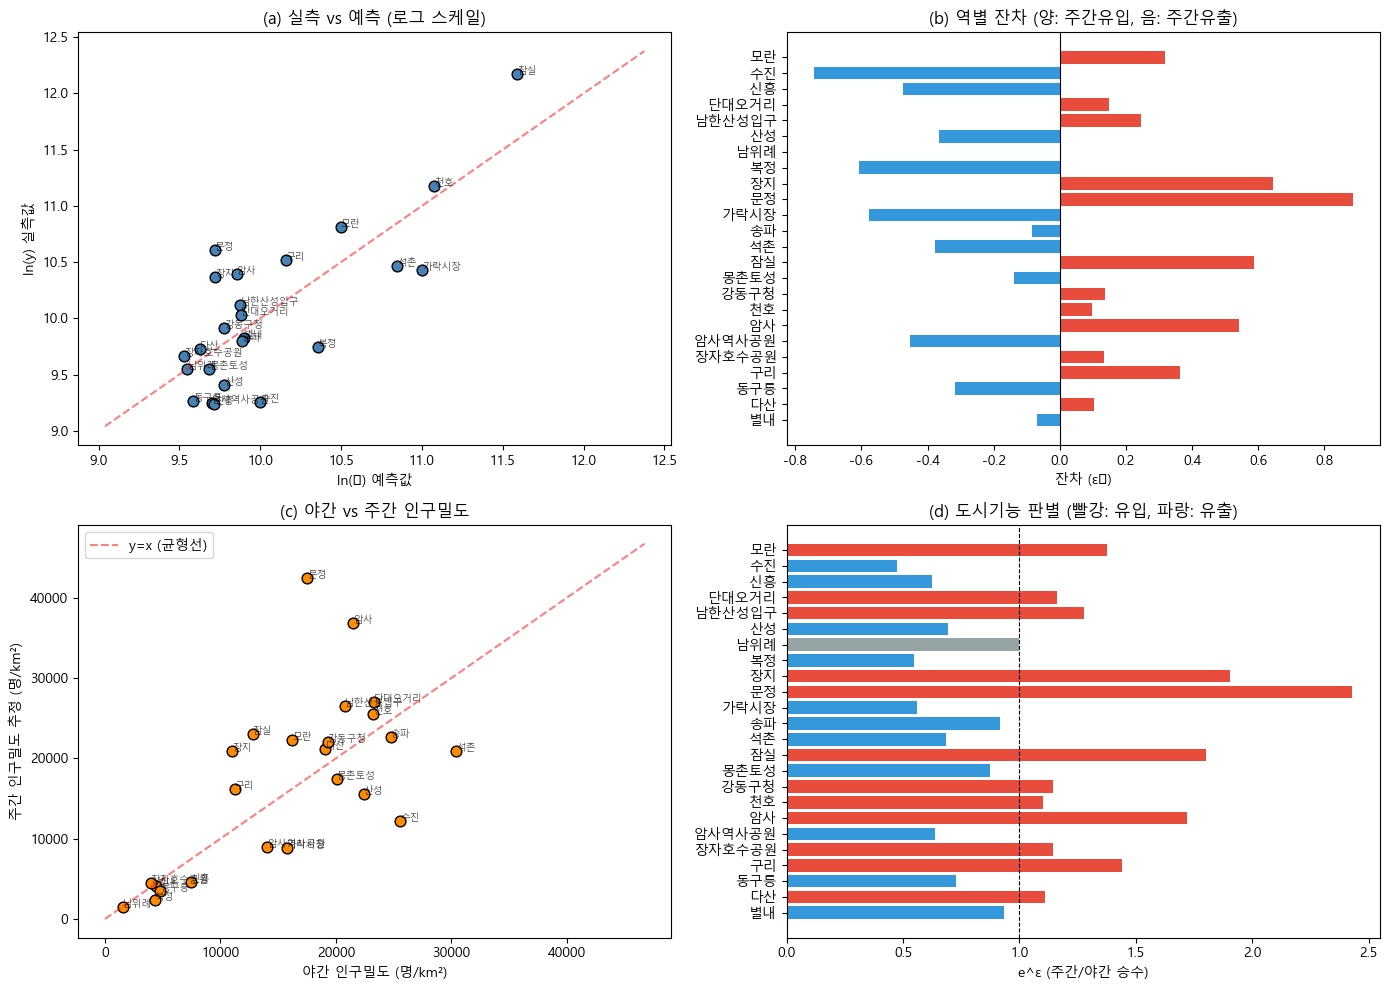

▶ 그래프 저장: 260414_figures.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) 실제 vs 예측 (로그 스케일)
ax = axes[0, 0]
ax.scatter(reg_df['ln_y_hat'], reg_df['ln_y'], c='steelblue', edgecolors='k', s=60)
for _, r in reg_df.iterrows():
    ax.annotate(r['역명'], (r['ln_y_hat'], r['ln_y']), fontsize=7, alpha=0.7)
lims = [min(reg_df['ln_y_hat'].min(), reg_df['ln_y'].min()) - 0.2,
        max(reg_df['ln_y_hat'].max(), reg_df['ln_y'].max()) + 0.2]
ax.plot(lims, lims, 'r--', alpha=0.5)
ax.set_xlabel('ln(ŷ) 예측값')
ax.set_ylabel('ln(y) 실측값')
ax.set_title('(a) 실측 vs 예측 (로그 스케일)')

# (2) 잔차 분포
ax = axes[0, 1]
ax.barh(reg_df['역명'], reg_df['residual'], color=['#e74c3c' if r > 0 else '#3498db' for r in reg_df['residual']])
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel('잔차 (ε̂)')
ax.set_title('(b) 역별 잔차 (양: 주간유입, 음: 주간유출)')

# (3) 야간 vs 주간 인구밀도
ax = axes[1, 0]
ax.scatter(reg_df['야간인구밀도'], reg_df['주간인구밀도_추정'], c='darkorange', edgecolors='k', s=60)
for _, r in reg_df.iterrows():
    ax.annotate(r['역명'], (r['야간인구밀도'], r['주간인구밀도_추정']), fontsize=7, alpha=0.7)
max_val = max(reg_df['야간인구밀도'].max(), reg_df['주간인구밀도_추정'].max()) * 1.1
ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='y=x (균형선)')
ax.set_xlabel('야간 인구밀도 (명/km²)')
ax.set_ylabel('주간 인구밀도 추정 (명/km²)')
ax.set_title('(c) 야간 vs 주간 인구밀도')
ax.legend()

# (4) e^ε 승수 바 차트
ax = axes[1, 1]
colors = ['#e74c3c' if e > 1.05 else ('#3498db' if e < 0.95 else '#95a5a6') for e in reg_df['exp_resid']]
ax.barh(reg_df['역명'], reg_df['exp_resid'], color=colors)
ax.axvline(1.0, color='k', linewidth=0.8, linestyle='--')
ax.set_xlabel('e^ε (주간/야간 승수)')
ax.set_title('(d) 도시기능 판별 (빨강: 유입, 파랑: 유출)')

plt.tight_layout()
plt.savefig(r'C:\Users\inwoo\260414_figures.png', dpi=150, bbox_inches='tight')
plt.show()
print("▶ 그래프 저장: 260414_figures.png")

## 6. 역세권 행정동 기본 정보 (표 4.2)

8호선 24개 역의 소재 행정동, 면적, 야간인구 및 야간인구밀도(명/km²) 현황 (2025년 12월 기준)

In [13]:
# ── 표 4.2: 역세권 행정동 기본 정보 ──
table_42 = density_df[['역번호', '행정동', '면적(km²)', '야간인구', '야간인구밀도']].copy()
table_42.insert(1, '역명', table_42['역번호'].map(name_map))
table_42['야간인구밀도'] = table_42['야간인구밀도'].astype(int)

print("▶ 표 4.2: 역세권 행정동 기본 정보")
display(table_42.style.set_properties(**{'text-align': 'center'}).hide(axis='index'))

▶ 표 4.2: 역세권 행정동 기본 정보


역번호,역명,행정동,면적(km²),야간인구,야간인구밀도
804,별내,별내동,18.630000,82897,4450
805,다산,다산1동,5.540000,105753,19089
806,동구릉,동구동,7.320000,35104,4796
807,구리,인창동,2.100000,23558,11218
808,장자호수공원,"수택3동, 교문2동",10.490000,41526,3959
809,암사역사공원,"암사제1동, 암사제3동",3.530000,49505,14024
810,암사,"암사제1동, 암사제2동",2.200000,47214,21461
811,천호,"천호제2동, 성내제2동, 풍납1동",3.010000,69818,23195
812,강동구청,"성내제1동, 풍납2동",2.170000,41839,19281
813,몽촌토성,"방이2동, 잠실4동",2.360000,47337,20058


## 7. 종합 분석 결과 요약

In [14]:
# ── 종합 요약 표 ──
summary = reg_df[['역번호', '역명', 'y', 'x11', 'x12', 'x13', 'K', 'L', 
                   '야간인구밀도', '주간인구밀도_추정', 'exp_resid', '유입유출']].copy()
summary.columns = ['역번호', '역명', '일평균승하차', 'x₁₁(0~14세)', 'x₁₂(15~64세)', 
                    'x₁₃(65세+)', 'K', 'L(km)', '야간밀도', '주간밀도(추정)', 
                    'e^ε', '도시기능']
summary['야간밀도'] = summary['야간밀도'].astype(int)
summary['주간밀도(추정)'] = summary['주간밀도(추정)'].round(0).astype(int)
summary['e^ε'] = summary['e^ε'].round(3)

print("▶ 종합 분석 결과")
display(summary.style.set_properties(**{'text-align': 'center'}).hide(axis='index'))

print(f"\n▶ 모형 요약:")
print(f"  R² = {model.rsquared:.4f} (Adj R² = {model.rsquared_adj:.4f})")
print(f"  관측수 = {int(model.nobs)}, 독립변수 = 5")
print(f"  주간 유입 역: {(reg_df['exp_resid'] > 1.05).sum()}개")
print(f"  주간 유출 역: {(reg_df['exp_resid'] < 0.95).sum()}개")
print(f"  균형 역: {((reg_df['exp_resid'] >= 0.95) & (reg_df['exp_resid'] <= 1.05)).sum()}개")

▶ 종합 분석 결과


역번호,역명,일평균승하차,x₁₁(0~14세),x₁₂(15~64세),x₁₃(65세+),K,L(km),야간밀도,주간밀도(추정),e^ε,도시기능
804,별내,18568,599.000000,3125.600000,725.100000,1.520000,3.550000,4450,4149,0.932000,주간 유출 (베드타운)
805,다산,16773,3277.800000,13241.900000,2569.300000,1.000000,2.450000,19089,21154,1.108000,주간 유입 (업무/상업)
806,동구릉,10582,440.800000,3475.700000,879.100000,1.000000,1.450000,4796,3494,0.729000,주간 유출 (베드타운)
807,구리,37065,1107.100000,8133.800000,1977.100000,1.720000,1.500000,11218,16138,1.439000,주간 유입 (업무/상업)
808,장자호수공원,15742,372.900000,2842.100000,743.600000,1.000000,2.700000,3959,4525,1.143000,주간 유입 (업무/상업)
809,암사역사공원,10372,1388.100000,9607.400000,3028.600000,1.000000,2.300000,14024,8924,0.636000,주간 유출 (베드타운)
810,암사,32695,1810.900000,14941.400000,4708.600000,1.000000,1.200000,21461,36883,1.719000,주간 유입 (업무/상업)
811,천호,71151,1382.400000,16635.200000,5177.700000,2.650000,1.100000,23195,25575,1.103000,주간 유입 (업무/상업)
812,강동구청,20186,1854.400000,13572.800000,3853.500000,1.000000,1.250000,19281,22077,1.145000,주간 유입 (업무/상업)
813,몽촌토성,14010,2083.900000,14730.500000,3243.600000,1.000000,1.200000,20058,17480,0.871000,주간 유출 (베드타운)



▶ 모형 요약:
  R² = 0.6218 (Adj R² = 0.5167)
  관측수 = 24, 독립변수 = 5
  주간 유입 역: 12개
  주간 유출 역: 11개
  균형 역: 1개
